In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, \
    Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam

from sklearn.utils import shuffle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2026-02-01 23:17:16.080861: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-01 23:17:16.109953: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-01 23:17:16.841211: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
!wget -nc http://files.grouplens.org/datasets/movielens/ml-20m.zip

--2026-02-01 23:17:28--  http://files.grouplens.org/datasets/movielens/ml-20m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-20m.zip [following]
--2026-02-01 23:17:30--  https://files.grouplens.org/datasets/movielens/ml-20m.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 198702078 (189M) [application/zip]
Saving to: ‘ml-20m.zip’

ml-20m.zip          100%[===================>] 189.50M  3.12MB/s    in 83s     

2026-02-01 23:18:53 (2.29 MB/s) - ‘ml-20m.zip’ saved [198702078/198702078]



In [3]:
!unzip -n ml-20m.zip

Archive:  ml-20m.zip
   creating: ml-20m/
  inflating: ml-20m/genome-scores.csv  
  inflating: ml-20m/genome-tags.csv  
  inflating: ml-20m/links.csv        
  inflating: ml-20m/movies.csv       
  inflating: ml-20m/ratings.csv      
  inflating: ml-20m/README.txt       
  inflating: ml-20m/tags.csv         


In [4]:
df = pd.read_csv('ml-20m/ratings.csv')
df.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [5]:
# We can't trust the userId and movieId to be numbered 0...N-1
# Let's just set our own ids

# current_user_id = 0
# custom_user_map = {} # old user id > new user id
# def map_user_id(row):
#   global current_user_id, custom_user_map
#   old_user_id = row['userId']
#   if old_user_id not in custom_user_map:
#     custom_user_map[old_user_id] = current_user_id
#     current_user_id += 1
#   return custom_user_map[old_user_id]

# df['new_user_id'] = df.apply(map_user_id, axis=1)

df.userId = pd.Categorical(df.userId)
df['new_user_id'] = df.userId.cat.codes

In [6]:
# Now do the same thing for movie ids
# current_movie_id = 0
# custom_movie_map = {} # old movie id > new movie id
# def map_movie_id(row):
#   global current_movie_id, custom_movie_map
#   old_movie_id = row['movieId']
#   if old_movie_id not in custom_movie_map:
#     custom_movie_map[old_movie_id] = current_movie_id
#     current_movie_id += 1
#   return custom_movie_map[old_movie_id]

# df['new_movie_id'] = df.apply(map_movie_id, axis=1)

df.movieId = pd.Categorical(df.movieId)
df['new_movie_id'] = df.movieId.cat.codes

In [7]:
# Get user IDs, movie IDs, and ratings as separate arrays
user_ids = df['new_user_id'].values
movie_ids = df['new_movie_id'].values
ratings = df['rating'].values

In [8]:
# Get number of users and number of movies
N = len(set(user_ids))
M = len(set(movie_ids))

# Set embedding dimension
K = 10

In [9]:
# Make a neural network

# User input
u = Input(shape=(1,))

# Movie input
m = Input(shape=(1,))

# User embedding
u_emb = Embedding(N, K)(u)  # output is (num_samples, 1, K)

# Movie embedding
m_emb = Embedding(M, K)(m)  # output is (num_samples, 1, K)

# Flatten both embeddings
u_emb = Flatten()(u_emb)  # now it's (num_samples, K)
m_emb = Flatten()(m_emb)  # now it's (num_samples, K)

# Concatenate user-movie embeddings into a feature vector
x = Concatenate()([u_emb, m_emb])  # now it's (num_samples, 2K)

# Now that we have a feature vector, it's just a regular ANN
x = Dense(1024, activation='relu')(x)
# x = Dense(400, activation='relu')(x)
# x = Dense(400, activation='relu')(x)
x = Dense(1)(x)

I0000 00:00:1769969941.692488 3499655 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3633 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [10]:
# Build the model and compile
model = Model(inputs=[u, m], outputs=x)
model.compile(
    loss='mse',
    optimizer=SGD(learning_rate=0.08, momentum=0.9),
)

In [11]:
# split the data
user_ids, movie_ids, ratings = shuffle(user_ids, movie_ids, ratings)
Ntrain = int(0.8 * len(ratings))
train_user = user_ids[:Ntrain]
train_movie = movie_ids[:Ntrain]
train_ratings = ratings[:Ntrain]

test_user = user_ids[Ntrain:]
test_movie = movie_ids[Ntrain:]
test_ratings = ratings[Ntrain:]

# center the ratings
avg_rating = train_ratings.mean()
train_ratings = train_ratings - avg_rating
test_ratings = test_ratings - avg_rating

In [12]:
r = model.fit(
    x=[train_user, train_movie],
    y=train_ratings,
    epochs=25,
    batch_size=1024,
    # verbose=2,  # goes a little faster when you don't print the progress bar
    validation_data=([test_user, test_movie], test_ratings),
)

Epoch 1/25


2026-02-01 23:19:27.698424: I external/local_xla/xla/service/service.cc:163] XLA service 0x70fe98003680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-01 23:19:27.698444: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-02-01 23:19:27.715742: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-01 23:19:27.739120: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


  168/15626 ━━━━━━━━━━━━━━━━━━━━ 13s 904us/step - loss: 1.1053

I0000 00:00:1769969968.066412 3554539 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15626/15626 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.7661 - val_loss: 0.7194
Epoch 2/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 0.6994 - val_loss: 0.6958
Epoch 3/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 0.6779 - val_loss: 0.6814
Epoch 4/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 0.6626 - val_loss: 0.6770
Epoch 5/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.6518 - val_loss: 0.6695
Epoch 6/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.6390 - val_loss: 0.6619
Epoch 7/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.6244 - val_loss: 0.6489
Epoch 8/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - loss: 0.6116 - val_loss: 0.6434
Epoch 9/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.6008 - val_loss: 0.6429
Epoch 10/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.5913 - val_loss: 0.6348
Epoch 11/25
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - loss: 0.5826 - val_loss: 0.6320
Epoch 12

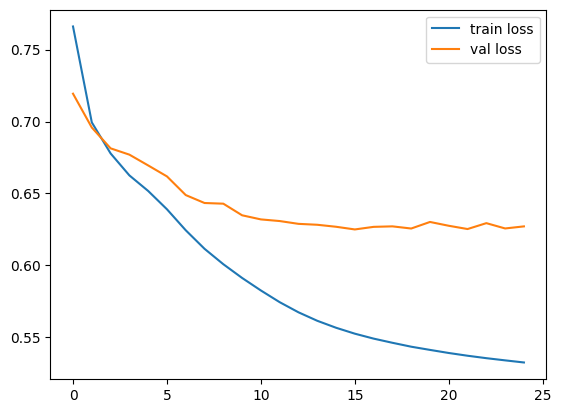

In [13]:
# plot losses
plt.plot(r.history['loss'], label="train loss")
plt.plot(r.history['val_loss'], label="val loss")
plt.legend()
plt.show()